In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

PROJECT_ROOT = Path.home() / "stress-detection"
save_dir=PROJECT_ROOT/"data"/"processed"
X_all=np.load(save_dir/"X_all.npy")
y_all=np.load(save_dir/"y_all.npy")


with open(save_dir/"subjects.json") as f:
    all_subjects=json.load(f)

label_names=["Baseline","Stress","Amusement","Meditation"]
SUBJECTS=sorted(set(all_subjects))

print(f"loaded X:{X_all.shape}")
print(f"loaded y:{y_all.shape}")
print(f"subjects:{SUBJECTS}")




loaded X:(1302, 42000, 4)
loaded y:(1302,)
subjects:['S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


In [2]:
import numpy as np

# Split subjects (not windows) into train/val/test
# 70% train /15% val /15% test -> 10/2/2 subjects

np.random.seed(42)
shuffled=SUBJECTS.copy()
np.random.shuffle(shuffled)

n=len(shuffled)

n_test=2
n_val=2
n_train=n-n_test-n_val

train_subjects=shuffled[:n_train]
val_subjects=shuffled[n_train:n_train+n_val]
test_subjects  = shuffled[n_train+n_val:]


print(f"Train subjects ({n_train}): {sorted(train_subjects)}")
print(f"Val   subjects ({n_val}):   {sorted(val_subjects)}")
print(f"Test  subjects ({n_test}):  {sorted(test_subjects)}")

# Build mask

Train subjects (10): ['S11', 'S13', 'S14', 'S16', 'S17', 'S4', 'S5', 'S7', 'S8', 'S9']
Val   subjects (2):   ['S3', 'S6']
Test  subjects (2):  ['S15', 'S2']


In [3]:
subjects_arr = np.array(all_subjects)

train_idx = np.where(np.isin(subjects_arr, train_subjects))[0]
val_idx   = np.where(np.isin(subjects_arr, val_subjects))[0]
test_idx  = np.where(np.isin(subjects_arr, test_subjects))[0]

# Downsample 700Hz → 70Hz (every 10th sample)
DOWNSAMPLE_FACTOR = 10
X_ds = X_all[:, ::DOWNSAMPLE_FACTOR, :]

X_train, y_train = X_ds[train_idx], y_all[train_idx]
X_val,   y_val   = X_ds[val_idx],   y_all[val_idx]
X_test,  y_test  = X_ds[test_idx],  y_all[test_idx]

N_TIMESTEPS = X_ds.shape[1]  # 4200
N_FEATURES  = X_ds.shape[2]  # 4

print(f"Downsampled shape : {X_ds.shape}  ({X_ds.nbytes/1e6:.0f} MB)")
print(f"Train : {len(X_train):>4} windows  subjects: {sorted(train_subjects)}")
print(f"Val   : {len(X_val):>4} windows  subjects: {sorted(val_subjects)}")
print(f"Test  : {len(X_test):>4} windows  subjects: {sorted(test_subjects)}")

# Free full-res data from memory
del X_all

Downsampled shape : (1302, 4200, 4)  (87 MB)
Train :  934 windows  subjects: ['S11', 'S13', 'S14', 'S16', 'S17', 'S4', 'S5', 'S7', 'S8', 'S9']
Val   :  184 windows  subjects: ['S3', 'S6']
Test  :  184 windows  subjects: ['S15', 'S2']


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

SEED = 42
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_CLASSES = 4
CLASS_NAMES = ['Baseline', 'Stress', 'Amusement', 'Meditation']
print(f"Device: {DEVICE}")

class WESADDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def make_weighted_sampler(y):
    counts = np.bincount(y, minlength=N_CLASSES).astype(float)
    weights = 1.0 / counts
    sample_weights = weights[y]
    return WeightedRandomSampler(
        weights     = torch.from_numpy(sample_weights).float(),
        num_samples = len(y),
        replacement = True
    )

BATCH_SIZE = 16

train_ds = WESADDataset(X_train, y_train)
val_ds   = WESADDataset(X_val,   y_val)
test_ds  = WESADDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=make_weighted_sampler(y_train), num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Sanity check
xb, yb = next(iter(train_loader))
print(f"Batch shape — X: {xb.shape}  y: {yb.shape}")
print(f"Batch label counts: {Counter(yb.numpy().tolist())}")

Device: cpu
Batch shape — X: torch.Size([16, 4200, 4])  y: torch.Size([16])
Batch label counts: Counter({1: 6, 3: 4, 2: 4, 0: 2})


In [5]:
class StressLSTM(nn.Module):
    def __init__(self, n_features, n_classes,
                 hidden_size=128, num_layers=2,
                 lstm_dropout=0.3, fc_dropout=0.4):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size    = n_features,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = lstm_dropout if num_layers > 1 else 0.0,
            bidirectional = False
        )
        self.norm = nn.LayerNorm(hidden_size)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(fc_dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        last_hidden  = h_n[-1]           # (batch, hidden_size)
        return self.classifier(self.norm(last_hidden))

model = StressLSTM(n_features=N_FEATURES, n_classes=N_CLASSES).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {total_params:,}")

# Forward pass test
with torch.no_grad():
    dummy = torch.zeros(2, N_TIMESTEPS, N_FEATURES).to(DEVICE)
    out   = model(dummy)
    print(f"Output shape: {out.shape}  ← should be (2, 4)")

StressLSTM(
  (lstm): LSTM(4, 128, num_layers=2, batch_first=True, dropout=0.3)
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)

Total parameters: 209,476
Output shape: torch.Size([2, 4])  ← should be (2, 4)


In [6]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

class_counts  = np.bincount(y_train, minlength=N_CLASSES).astype(float)
class_weights = torch.tensor(
    (1.0 / class_counts) / (1.0 / class_counts).sum() * N_CLASSES,
    dtype=torch.float32
).to(DEVICE)

print("Class weights:")
for name, w in zip(CLASS_NAMES, class_weights):
    print(f"  {name:<12}: {w:.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = ReduceLROnPlateau(optimizer, mode='min', patience=5,
                                factor=0.5, min_lr=1e-5)

Class weights:
  Baseline    : 0.5101
  Stress      : 0.9270
  Amusement   : 1.7528
  Meditation  : 0.8101


In [7]:
from sklearn.metrics import f1_score, accuracy_score

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            preds = logits.argmax(dim=1)
            correct    += (preds == y_batch).sum().item()
            total      += len(y_batch)
            total_loss += loss.item() * len(y_batch)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    return (total_loss / total,
            correct / total,
            f1_score(all_labels, all_preds, average='macro', zero_division=0))


N_EPOCHS   = 50
EARLY_STOP = 10
MODEL_DIR  = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)

history = {k: [] for k in
           ['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1']}

best_val_loss, patience_counter, best_epoch = float('inf'), 0, 0

print(f"{'Ep':>4}  {'TrLoss':>8} {'TrAcc':>7} {'TrF1':>6}  "
      f"{'VlLoss':>8} {'VlAcc':>7} {'VlF1':>6}  {'LR':>8}")
print("─" * 68)

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, vl_f1 = run_epoch(model, val_loader,   criterion)
    scheduler.step(vl_loss)
    lr = optimizer.param_groups[0]['lr']

    for k, v in zip(history, [tr_loss,vl_loss,tr_acc,vl_acc,tr_f1,vl_f1]):
        history[k].append(v)

    marker = ''
    if vl_loss < best_val_loss:
        best_val_loss, best_epoch, patience_counter = vl_loss, epoch, 0
        torch.save(model.state_dict(), MODEL_DIR / 'best_model.pt')
        marker = ' ←'
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP:
            print(f"\nEarly stop at epoch {epoch}  (best: {best_epoch})")
            break

    print(f"{epoch:>4}  {tr_loss:>8.4f} {tr_acc:>7.3f} {tr_f1:>6.3f}  "
          f"{vl_loss:>8.4f} {vl_acc:>7.3f} {vl_f1:>6.3f}  {lr:>8.2e}{marker}")

print("─" * 68)
print(f"Best epoch: {best_epoch}  val_loss: {best_val_loss:.4f}")

  Ep    TrLoss   TrAcc   TrF1    VlLoss   VlAcc   VlF1        LR
────────────────────────────────────────────────────────────────────
   1    1.2637   0.312  0.237    1.5243   0.174  0.135  1.00e-03 ←
   2    1.1996   0.367  0.297    1.6078   0.179  0.141  1.00e-03
   3    1.2066   0.342  0.293    1.6628   0.239  0.220  1.00e-03
   4    1.2037   0.355  0.307    1.6027   0.185  0.146  1.00e-03
   5    1.1687   0.367  0.299    1.5784   0.272  0.263  1.00e-03
   6    1.1861   0.338  0.265    1.5676   0.261  0.242  1.00e-03
   7    1.1912   0.363  0.300    1.6824   0.207  0.172  5.00e-04
   8    1.1820   0.362  0.280    1.5838   0.228  0.201  5.00e-04
   9    1.1438   0.396  0.292    1.6222   0.228  0.200  5.00e-04
  10    1.1531   0.384  0.314    1.5454   0.234  0.213  5.00e-04
  11    1.1838   0.363  0.319    1.4946   0.277  0.274  5.00e-04 ←
  12    1.1774   0.400  0.354    1.5275   0.250  0.231  5.00e-04
  13    1.1371   0.400  0.366    1.5057   0.283  0.284  5.00e-04
  14    1.1548   

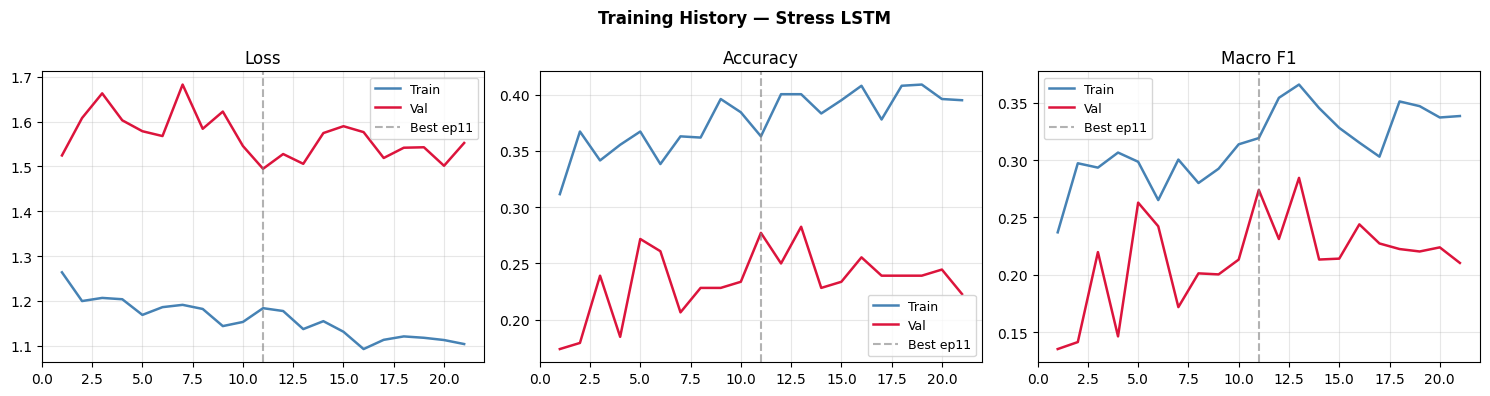

In [8]:
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Training History — Stress LSTM', fontweight='bold')

for ax, (title, tk, vk) in zip(axes, [
    ('Loss',     'train_loss', 'val_loss'),
    ('Accuracy', 'train_acc',  'val_acc'),
    ('Macro F1', 'train_f1',   'val_f1'),
]):
    ax.plot(epochs_ran, history[tk], label='Train', color='steelblue', lw=1.8)
    ax.plot(epochs_ran, history[vk], label='Val',   color='crimson',   lw=1.8)
    ax.axvline(best_epoch, color='gray', ls='--', alpha=0.6, label=f'Best ep{best_epoch}')
    ax.set_title(title); ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Test Accuracy : 19.0%
Macro F1      : 0.1684

              precision    recall  f1-score   support

    Baseline       0.50      0.07      0.12        75
      Stress       0.33      0.57      0.42        40
   Amusement       0.06      0.27      0.10        22
  Meditation       0.25      0.02      0.04        47

    accuracy                           0.19       184
   macro avg       0.28      0.23      0.17       184
weighted avg       0.35      0.19      0.16       184



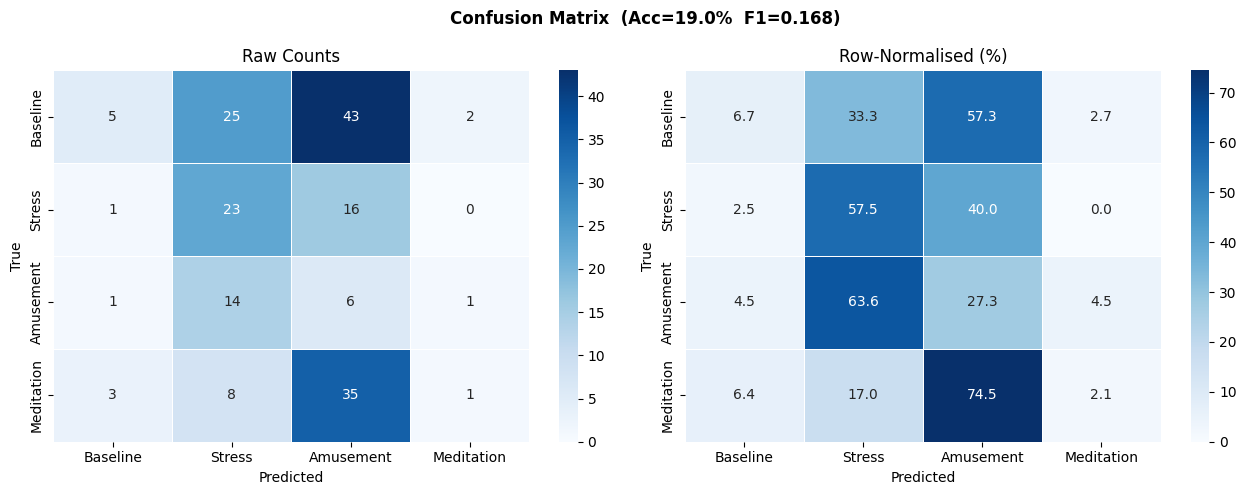

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load(MODEL_DIR / 'best_model.pt', map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(DEVICE)).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc      = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print(f"Test Accuracy : {acc*100:.1f}%")
print(f"Macro F1      : {macro_f1:.4f}\n")
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, zero_division=0))

# Confusion matrix
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Confusion Matrix  (Acc={acc*100:.1f}%  F1={macro_f1:.3f})',
             fontweight='bold')

for ax, (data, fmt, title) in zip(axes, [
    (cm,      'd',   'Raw Counts'),
    (cm_norm, '.1f', 'Row-Normalised (%)'),
]):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5)
    ax.set_title(title)
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

results = {
    'model'           : 'StressLSTM-2layer',
    'dataset'         : 'WESAD',
    'n_classes'       : N_CLASSES,
    'class_names'     : CLASS_NAMES,
    'train_subjects'  : sorted(train_subjects),
    'val_subjects'    : sorted(val_subjects),
    'test_subjects'   : sorted(test_subjects),
    'total_windows'   : int(len(y_all)),
    'input_shape'     : [N_TIMESTEPS, N_FEATURES],
    'best_epoch'      : best_epoch,
    'test_accuracy'   : round(float(acc), 4),
    'test_macro_f1'   : round(float(macro_f1), 4),
    'per_class_f1'    : {n: round(float(f), 4)
                         for n, f in zip(CLASS_NAMES, per_class_f1)},
    'confusion_matrix': cm.tolist()
}

with open(OUTPUT_DIR / 'results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Saved: outputs/results.json")
print(f"\n{'─'*35}")
print("FINAL RESULTS")
print(f"{'─'*35}")
print(f"  Accuracy : {acc*100:.1f}%")
print(f"  Macro F1 : {macro_f1:.4f}")
for name, f in zip(CLASS_NAMES, per_class_f1):
    print(f"  {name:<12}: F1 = {f:.4f}")
print(f"{'─'*35}")
print(f"\nOutputs saved to: {OUTPUT_DIR}")

Saved: outputs/results.json

───────────────────────────────────
FINAL RESULTS
───────────────────────────────────
  Accuracy : 19.0%
  Macro F1 : 0.1684
  Baseline    : F1 = 0.1176
  Stress      : F1 = 0.4182
  Amusement   : F1 = 0.0984
  Meditation  : F1 = 0.0392
───────────────────────────────────

Outputs saved to: /home/praruj/stress-detection/outputs
